In [17]:
!pip install ultralytics==8.3.0
from google.colab import drive
drive.mount('/dlcnn')


from ultralytics import RTDETR
import shutil, os, torch, warnings

warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

ROOT = "/dlcnn/MyDrive/"
DATA_YAML = "/content/dataset/data.yaml"

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

import gc
import torch

# Clear Python/RAM
gc.collect()

# Clear VRAM
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

Drive already mounted at /dlcnn; to attempt to forcibly remount, call drive.mount("/dlcnn", force_remount=True).
True
NVIDIA A100-SXM4-80GB


In [ ]:
!curl -L "https://app.roboflow.com/ds/D8Vg437Oeb?key=8wlKDfwToQ" >  /content/dataset.zip
!unzip -q /content/dataset.zip -d /content/dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   903  100   903    0     0   2247      0 --:--:-- --:--:-- --:--:--  2246
100  576M  100  576M    0     0  29.3M      0  0:00:19  0:00:19 --:--:-- 31.3M
replace /content/dataset/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


# RT-DETR Large (Transfer) training

In [18]:
!cat /usr/local/lib/python3.12/dist-packages/ultralytics/cfg/default.yaml

# Ultralytics YOLO 🚀, AGPL-3.0 license
# Default training settings and hyperparameters for medium-augmentation COCO training

task: detect # (str) YOLO task, i.e. detect, segment, classify, pose
mode: train # (str) YOLO mode, i.e. train, val, predict, export, track, benchmark

# Train settings -------------------------------------------------------------------------------------------------------
model: # (str, optional) path to model file, i.e. yolov8n.pt, yolov8n.yaml
data: # (str, optional) path to data file, i.e. coco8.yaml
epochs: 100 # (int) number of epochs to train for
time: # (float, optional) number of hours to train for, overrides epochs if supplied
patience: 100 # (int) epochs to wait for no observable improvement for early stopping of training
batch: 16 # (int) number of images per batch (-1 for AutoBatch)
imgsz: 640 # (int | list) input images size as int for train and val modes, or list[h,w] for predict and export modes
save: True # (bool) save train checkpoints and predi

In [19]:
import torch
import gc

# Clean memory before the training
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory free: {torch.cuda.mem_get_info()[0]/1e9:.2f}GB")

import os
os.chdir(ROOT)

model = RTDETR("rtdetr-l.pt")
model.train(
    data=DATA_YAML,
    epochs=150,
    batch=64,
    cache="ram",
    workers=8,
    project="runs",
    name="rtdetr-default",
    exist_ok=False,
)

import os
os.makedirs(ROOT + "models", exist_ok=True)
shutil.copy(ROOT + "runs/rtdetr-l-default/weights/best.pt", ROOT + "models/rtdetr-l-default.pt")

GPU memory free: 81.18GB
New https://pypi.org/project/ultralytics/8.4.53 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: task=detect, mode=train, model=rtdetr-l.pt, data=/content/dataset/data.yaml, epochs=150, time=None, patience=100, batch=64, imgsz=640, save=True, save_period=-1, cache=ram, device=None, workers=8, project=runs, name=rtdetr-default, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_ma

train: Scanning /content/dataset/train/labels.cache... 7353 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7353/7353 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/dataset/train/images/190_jpg.rf.7022c064680bdbee866a35758df1078a.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/dataset/train/images/264_jpg.rf.0f08bf974f97ac3ec8b86f18ac49236a.jpg: 2 duplicate labels removed
train: WARNING ⚠️ /content/dataset/train/images/264_jpg.rf.21a5ebc0fe2f1e01f4c70e95deb3194a.jpg: 2 duplicate labels removed
train: WARNING ⚠️ /content/dataset/train/images/308_jpg.rf.00d32b5de0fa24f9c82a3381814cb212.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/dataset/train/images/315_jpg.rf.8e6cca8d21141ef7daeeb2828b486ad0.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/dataset/train/images/315_jpg.rf.aaa45f92f900718c247e09ea7dc3f298.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/dataset/train/images/388_jpg.rf.96974ed6833e13cf10aaa123dc004ddc.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/dataset/train/images/388_jpg.rf.ae9f369ffacaade84a4c552850118d4f.jpg: 1 duplicate labels removed
train: W


train: Caching images (8.4GB RAM): 100%|██████████| 7353/7353 [00:03<00:00, 2417.96it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

                   all       1576       2887       0.58      0.405      0.404       0.29

150 epochs completed in 4.846 hours.
Optimizer stripped from runs/rtdetr-default/weights/last.pt, 66.2MB
Optimizer stripped from runs/rtdetr-default/weights/best.pt, 66.2MB

Validating runs/rtdetr-default/weights/best.pt...
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
rt-detr-l summary: 502 layers, 31,996,070 parameters, 0 gradients, 103.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:10<00:00,  1.19it/s]


                   all       1576       2887      0.583      0.405      0.404       0.29
                Hammer        148        276      0.499      0.231      0.223       0.14
                 Knife        774       1236      0.541      0.347      0.341      0.205
              Scissors        272        494        0.5      0.309      0.333      0.204
           Screwdriver        162        319      0.406      0.166       0.16      0.101
                 Spill        135        139      0.959      0.999      0.994      0.828
                  Tape        293        423      0.593      0.379      0.376      0.262
Speed: 0.1ms preprocess, 2.4ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/rtdetr-default


lr/pg0,▃████▇▇▇▇▇▇▆▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁
lr/pg1,█████▇▇▇▇▇▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁
lr/pg2,█████▇▇▇▇▇▆▆▆▅▅▅▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
metrics/mAP50(B),▂▁▄▅▃▄▆▆▆▆▇▇▇▇▇▇▇▇▇█▇██████▇▇▇▇▇▇▇▆█████
metrics/mAP50-95(B),▁▅▆▄▅▆▆▆▇▇▆▇▇▇▇▇▇▇▇████████████▇▇███████
metrics/precision(B),▁▄▆▆▆▇▇▇▇▇▇▆▇▇▇█▇▇▇▇▇▇▇▇▇▇████▇▇███▇▇▇██
metrics/recall(B),▁▄▆▆▆▇▇▇▇▇▇▇▇▇▇█▇▇▇▇███▇████████▇███████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...


FileNotFoundError: [Errno 2] No such file or directory: '/dlcnn/MyDrive/runs/rtdetr-l-default/weights/best.pt'

# Visualise the training

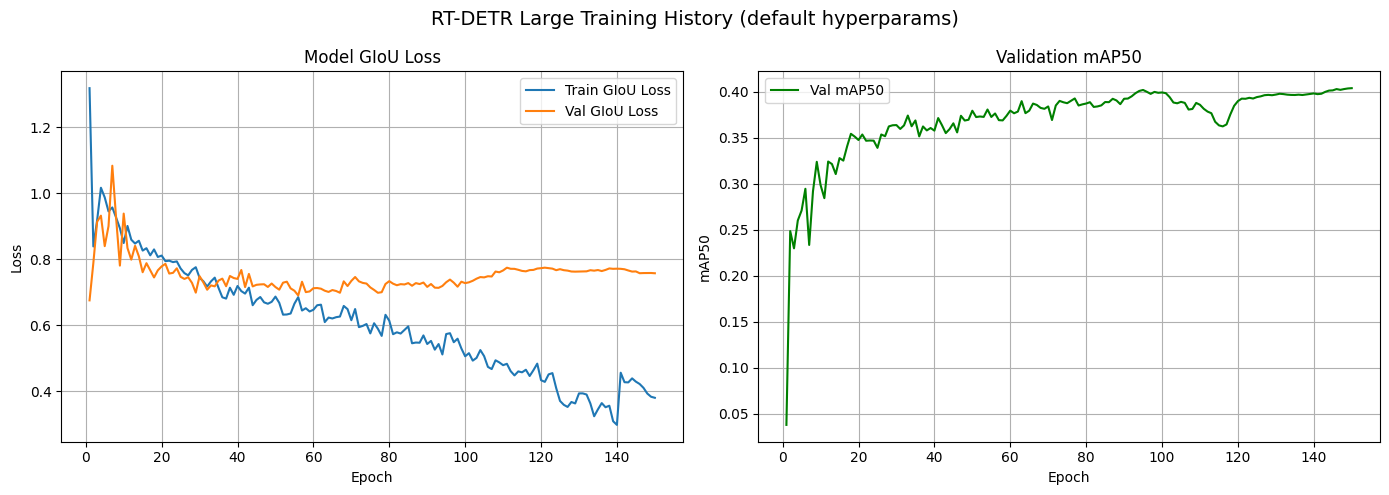

In [21]:
import os
os.makedirs(ROOT + "models", exist_ok=True)
shutil.copy(ROOT + "runs/rtdetr-default/weights/best.pt", ROOT + "models/rtdetr-l-default.pt")

import torch
import gc

!pip install matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

results = pd.read_csv(ROOT + "runs/rtdetr-default/results.csv")
results.columns = results.columns.str.strip()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(results["epoch"], results["train/giou_loss"], label="Train GIoU Loss")
ax1.plot(results["epoch"], results["val/giou_loss"], label="Val GIoU Loss")
ax1.set_title("Model GIoU Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(results["epoch"], results["metrics/mAP50(B)"], label="Val mAP50", color="green")
ax2.set_title("Validation mAP50")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("mAP50")
ax2.legend()
ax2.grid(True)

plt.suptitle("RT-DETR Large Training History (default hyperparams)", fontsize=14)
plt.tight_layout()
plt.show()

# The model accuracy on Train, Val and Test datasets

In [25]:
model = RTDETR(ROOT + "/models/rtdetr-l-default.pt")
train_metrics = model.val(data=DATA_YAML, split="train")
val_metrics = model.val(data=DATA_YAML, split="val")
test_metrics = model.val(data=DATA_YAML, split="test")
print(f"Train mAP@50: {train_metrics.box.map50:.4f}")
print(f"Val   mAP@50: {val_metrics.box.map50:.4f}")
print(f"Test  mAP@50: {test_metrics.box.map50:.4f}")

Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
rt-detr-l summary: 502 layers, 31,996,070 parameters, 0 gradients, 103.5 GFLOPs


val: Scanning /content/dataset/train/labels.cache... 7353 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7353/7353 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/dataset/train/images/190_jpg.rf.7022c064680bdbee866a35758df1078a.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/dataset/train/images/264_jpg.rf.0f08bf974f97ac3ec8b86f18ac49236a.jpg: 2 duplicate labels removed
train: WARNING ⚠️ /content/dataset/train/images/264_jpg.rf.21a5ebc0fe2f1e01f4c70e95deb3194a.jpg: 2 duplicate labels removed
train: WARNING ⚠️ /content/dataset/train/images/308_jpg.rf.00d32b5de0fa24f9c82a3381814cb212.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/dataset/train/images/315_jpg.rf.8e6cca8d21141ef7daeeb2828b486ad0.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/dataset/train/images/315_jpg.rf.aaa45f92f900718c247e09ea7dc3f298.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/dataset/train/images/388_jpg.rf.96974ed6833e13cf10aaa123dc004ddc.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/dataset/train/images/388_jpg.rf.ae9f369ffacaade84a4c552850118d4f.jpg: 1 duplicate labels removed
train: W


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 460/460 [01:05<00:00,  6.98it/s]
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ac0ce1fb920>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1671, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            

                   all       7353      11005      0.926      0.811      0.877      0.661
                Hammer       1669       2164      0.932      0.842      0.903      0.699
                 Knife        715       1079      0.874      0.783      0.861      0.617
              Scissors       1532       2109      0.919      0.771      0.857      0.603
           Screwdriver       1099       1678       0.92      0.672      0.776      0.535
                 Spill       1515       1588      0.993      0.999      0.995      0.857
                  Tape       1814       2387      0.918      0.798      0.867      0.655
Speed: 0.1ms preprocess, 4.6ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/val4
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
rt-detr-l summary: 502 layers, 31,996,070 parameters, 0 gradients, 103.5 GFLOPs


...

                   all       1576       2887      0.582      0.405      0.403       0.29
                Hammer        148        276      0.494       0.23      0.222      0.141
                 Knife        774       1236      0.538      0.346      0.339      0.205
              Scissors        272        494      0.502      0.312      0.333      0.205
           Screwdriver        162        319      0.407      0.166      0.159      0.101
                 Spill        135        139      0.959      0.999      0.994      0.826
                  Tape        293        423       0.59      0.377      0.372      0.261
Speed: 0.1ms preprocess, 4.7ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to runs/detect/val5
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
rt-detr-l summary: 502 layers, 31,996,070 parameters, 0 gradients, 103.5 GFLOPs


val: Scanning /content/dataset/test/labels.cache... 1575 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1575/1575 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/dataset/test/images/240_jpg.rf.d3329f31b51fa3ef9f8bc6086d2542dc.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/dataset/test/images/248_jpg.rf.aa99af9cef0ded6a5a85dc893f2ce56c.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/dataset/test/images/410_jpg.rf.984c50fc035b5c4af0033e545891dbbc.jpg: 1 duplicate labels removed



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 99/99 [00:15<00:00,  6.57it/s]


                   all       1575       2870      0.597      0.448      0.446      0.315
                Hammer        114        168      0.528      0.446      0.415      0.261
                 Knife        707       1152      0.548      0.363      0.353      0.213
              Scissors        261        543      0.548      0.381      0.374      0.247
           Screwdriver        155        312      0.381      0.173      0.173      0.104
                 Spill        267        291      0.992      0.993      0.995      0.825
                  Tape        261        404      0.584      0.334      0.368      0.243
Speed: 0.1ms preprocess, 4.7ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/val6
Train mAP@50: 0.8766
Val   mAP@50: 0.4033
Test  mAP@50: 0.4464
